# Week 8: Decision-Score Routing and Human Review

This notebook evaluates a human-review policy for the locked Version 1 TF-IDF + Linear SVM baseline. It reconstructs the corrected leakage-safe 2024 split, generates development-only out-of-fold (OOF) decision scores, selects routing thresholds without using the final test set, and then evaluates the locked policy once on the untouched final internal test fold.

Linear SVM decision scores and score margins are model signals, **not calibrated probabilities**. The maximum 5% development misroute rate used here is an internal project assumption, not a production-approved standard.

Privacy guardrails: do not load 2025 data, display complaint narratives, or export row-level scores or predictions.

## 1. Imports, Paths, and Locked Design

In [1]:
from pathlib import Path
import hashlib
import sys
import textwrap

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def find_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        expected = candidate / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
        if expected.exists() and (candidate / ".gitignore").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root and local 2024 processed dataset.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.routing_rules import AUTO_ROUTE, route_from_scores


DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cfpb_complaints_2024_cleaned.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "best_tfidf_classifier.joblib"
FIGURE_PATH = PROJECT_ROOT / "reports" / "figures" / "routing_decision_score_summary.png"

LOCKED_CATEGORIES = (
    "Credit reporting or other personal consumer reports",
    "Debt collection",
    "Credit card",
    "Checking or savings account",
    "Mortgage",
    "Money transfer, virtual currency, or money service",
    "Student loan",
    "Vehicle loan or lease",
)
EXPECTED_MODELING_ROWS = 33_042
EXPECTED_DEVELOPMENT_ROWS = 26_433
EXPECTED_FINAL_TEST_ROWS = 6_609
OUTER_SPLITS = 5
DEVELOPMENT_CV_SPLITS = 5
FINAL_TEST_FOLD = 0
RANDOM_STATE = 42

MAX_DEVELOPMENT_MISROUTE_RATE = 0.05
MIN_DEVELOPMENT_COVERAGE = 0.05
CANDIDATE_QUANTILES = np.arange(0.0, 1.0, 0.025)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dataset: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Local model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print("2025 holdout status: not loaded or used.")

Project root: E:\MGA\ITEC6740\Final-Project\financial-complaint-auto-routing-nlp
Input dataset: data\processed\cfpb_complaints_2024_cleaned.csv
Local model: models\best_tfidf_classifier.joblib
2025 holdout status: not loaded or used.


## 2. Reconstruct the Corrected Leakage-Safe Split

In [2]:
source_df = pd.read_csv(DATA_PATH)

required_columns = {"clean_complaint_text", "product"}
missing_columns = sorted(required_columns.difference(source_df.columns))
if missing_columns:
    raise ValueError(f"Missing required modeling columns: {missing_columns}")
if source_df[list(required_columns)].isna().any().any():
    raise ValueError("The processed modeling columns must not contain missing values.")


def normalize_cleaned_text(value: object) -> str:
    return " ".join(str(value).strip().split())


def stable_text_hash(value: object) -> str:
    normalized = normalize_cleaned_text(value)
    if not normalized:
        raise ValueError("Normalized complaint text must not be empty.")
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


working_df = source_df[["clean_complaint_text", "product"]].copy()
working_df["normalized_text_hash"] = working_df["clean_complaint_text"].map(stable_text_hash)

label_counts_by_hash = working_df.groupby("normalized_text_hash", sort=False)["product"].nunique()
conflicting_hashes = set(label_counts_by_hash[label_counts_by_hash > 1].index)

locked_scope_df = working_df[working_df["product"].isin(LOCKED_CATEGORIES)].copy()
locked_scope_df = locked_scope_df[
    ~locked_scope_df["normalized_text_hash"].isin(conflicting_hashes)
].copy()
remediated_df = locked_scope_df.drop_duplicates(
    subset=["normalized_text_hash", "product"],
    keep="first",
).reset_index(drop=True)

assert len(remediated_df) == EXPECTED_MODELING_ROWS
assert remediated_df["normalized_text_hash"].is_unique
assert remediated_df.groupby("normalized_text_hash")["product"].nunique().max() == 1
assert set(remediated_df["product"].unique()) == set(LOCKED_CATEGORIES)

outer_splitter = StratifiedGroupKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
outer_folds = list(
    outer_splitter.split(
        remediated_df["clean_complaint_text"],
        remediated_df["product"],
        groups=remediated_df["normalized_text_hash"],
    )
)
development_indices, final_test_indices = outer_folds[FINAL_TEST_FOLD]
development_df = remediated_df.iloc[development_indices].reset_index(drop=True)
final_test_df = remediated_df.iloc[final_test_indices].reset_index(drop=True)

development_groups = set(development_df["normalized_text_hash"])
final_test_groups = set(final_test_df["normalized_text_hash"])

assert len(development_df) == EXPECTED_DEVELOPMENT_ROWS
assert len(final_test_df) == EXPECTED_FINAL_TEST_ROWS
assert not development_groups.intersection(final_test_groups)
assert set(development_df["product"].unique()) == set(LOCKED_CATEGORIES)
assert set(final_test_df["product"].unique()) == set(LOCKED_CATEGORIES)

print("Locked split reconstruction:")
print(f"- Corrected modeling rows: {len(remediated_df):,}")
print(f"- Development rows: {len(development_df):,}")
print(f"- Final internal test rows: {len(final_test_df):,}")
print(f"- Development/final-test normalized-text overlap: {len(development_groups & final_test_groups):,}")
print(f"- Locked categories present in both splits: {len(LOCKED_CATEGORIES)}")

Locked split reconstruction:
- Corrected modeling rows: 33,042
- Development rows: 26,433
- Final internal test rows: 6,609
- Development/final-test normalized-text overlap: 0
- Locked categories present in both splits: 8


## 3. Load and Validate the Locked Fitted Pipeline

In [3]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Required local model artifact not found: {MODEL_PATH}")

locked_pipeline = joblib.load(MODEL_PATH)

assert isinstance(locked_pipeline, Pipeline)
assert list(locked_pipeline.named_steps) == ["tfidf", "classifier"]
assert isinstance(locked_pipeline.named_steps["tfidf"], TfidfVectorizer)
assert isinstance(locked_pipeline.named_steps["classifier"], LinearSVC)

tfidf = locked_pipeline.named_steps["tfidf"]
classifier = locked_pipeline.named_steps["classifier"]
assert tfidf.max_features == 50_000
assert tfidf.ngram_range == (1, 2)
assert tfidf.min_df == 2
assert classifier.random_state == RANDOM_STATE
assert classifier.class_weight == "balanced"
assert classifier.max_iter == 10_000

pipeline_class_order = list(locked_pipeline.classes_)
assert len(pipeline_class_order) == len(LOCKED_CATEGORIES)
assert set(pipeline_class_order) == set(LOCKED_CATEGORIES)

print("Validated local pipeline: TF-IDF + Linear SVM")
print("Pipeline class order from classes_:")
for class_index, class_name in enumerate(pipeline_class_order):
    print(f"  {class_index}: {class_name}")
print("Decision-score columns will use this fitted class order.")

Validated local pipeline: TF-IDF + Linear SVM
Pipeline class order from classes_:
  0: Checking or savings account
  1: Credit card
  2: Credit reporting or other personal consumer reports
  3: Debt collection
  4: Money transfer, virtual currency, or money service
  5: Mortgage
  6: Student loan
  7: Vehicle loan or lease
Decision-score columns will use this fitted class order.


## 4. Development-Only Out-of-Fold Decision Scores

Each development fold refits a cloned copy of the locked pipeline configuration. The final internal test set is not scored or referenced during this stage.

In [4]:
development_cv = StratifiedGroupKFold(
    n_splits=DEVELOPMENT_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
development_cv_folds = list(
    development_cv.split(
        development_df["clean_complaint_text"],
        development_df["product"],
        groups=development_df["normalized_text_hash"],
    )
)

oof_score_matrix = np.full(
    (len(development_df), len(pipeline_class_order)),
    np.nan,
    dtype=float,
)

for fold_number, (fold_train_indices, fold_validation_indices) in enumerate(development_cv_folds):
    fold_train_df = development_df.iloc[fold_train_indices]
    fold_validation_df = development_df.iloc[fold_validation_indices]
    fold_train_groups = set(fold_train_df["normalized_text_hash"])
    fold_validation_groups = set(fold_validation_df["normalized_text_hash"])
    assert not fold_train_groups.intersection(fold_validation_groups)

    fold_pipeline = clone(locked_pipeline)
    fold_pipeline.fit(
        fold_train_df["clean_complaint_text"],
        fold_train_df["product"],
    )
    assert list(fold_pipeline.classes_) == pipeline_class_order

    fold_scores = fold_pipeline.decision_function(
        fold_validation_df["clean_complaint_text"]
    )
    assert fold_scores.shape == (len(fold_validation_df), len(pipeline_class_order))
    oof_score_matrix[fold_validation_indices] = fold_scores

assert np.isfinite(oof_score_matrix).all()

oof_top_indices = np.argmax(oof_score_matrix, axis=1)
oof_sorted_scores = np.sort(oof_score_matrix, axis=1)
oof_top_scores = oof_sorted_scores[:, -1]
oof_second_scores = oof_sorted_scores[:, -2]
oof_score_margins = oof_top_scores - oof_second_scores
oof_predictions = np.asarray(pipeline_class_order, dtype=object)[oof_top_indices]
oof_is_correct = oof_predictions == development_df["product"].to_numpy()

development_oof = pd.DataFrame(
    {
        "actual_label": development_df["product"].to_numpy(),
        "predicted_label": oof_predictions,
        "top_score": oof_top_scores,
        "second_score": oof_second_scores,
        "score_margin": oof_score_margins,
        "is_correct": oof_is_correct,
    }
)

assert len(development_oof) == EXPECTED_DEVELOPMENT_ROWS
assert development_oof[["top_score", "second_score", "score_margin"]].notna().all().all()
assert (development_oof["score_margin"] >= 0).all()

print("Development OOF scoring complete:")
print(f"- Folds: {len(development_cv_folds)}")
print(f"- OOF rows scored exactly once: {len(development_oof):,}")
print(f"- OOF prediction accuracy: {development_oof['is_correct'].mean():.4f}")
print("- Row-level scores and predictions remain in memory only.")

Development OOF scoring complete:
- Folds: 5
- OOF rows scored exactly once: 26,433
- OOF prediction accuracy: 0.8735
- Row-level scores and predictions remain in memory only.


## 5. Select and Lock Routing Thresholds on Development OOF Results

Candidate thresholds are the two-decimal values at 2.5-percentage-point quantiles of the development OOF top scores and margins. Rounding creates an interpretable candidate grid. A policy qualifies when development OOF misroute rate is at most 5% and coverage is at least 5%. The qualifying policy with highest coverage is selected; ties favor lower misroute rate, then lower top-score and margin thresholds.

The 5% limit is an internal analytical assumption for this project. It is not a production-approved risk standard.

In [5]:
def routing_metrics(is_correct: np.ndarray, auto_route_mask: np.ndarray) -> dict[str, float | int]:
    total_rows = int(auto_route_mask.size)
    auto_routed_rows = int(auto_route_mask.sum())
    reviewed_rows = total_rows - auto_routed_rows
    if auto_routed_rows == 0:
        auto_routed_accuracy = np.nan
        misroute_rate = np.nan
    else:
        auto_routed_accuracy = float(is_correct[auto_route_mask].mean())
        misroute_rate = 1.0 - auto_routed_accuracy
    return {
        "rows": total_rows,
        "auto_routed_rows": auto_routed_rows,
        "reviewed_rows": reviewed_rows,
        "coverage": auto_routed_rows / total_rows,
        "review_rate": reviewed_rows / total_rows,
        "auto_routed_accuracy": auto_routed_accuracy,
        "misroute_rate": misroute_rate,
    }


top_score_candidates = np.unique(
    np.round(np.quantile(oof_top_scores, CANDIDATE_QUANTILES), 2)
)
score_margin_candidates = np.unique(
    np.round(np.quantile(oof_score_margins, CANDIDATE_QUANTILES), 2)
)

candidate_rows = []
for min_top_score in top_score_candidates:
    for min_score_margin in score_margin_candidates:
        candidate_mask = (
            (oof_top_scores >= min_top_score)
            & (oof_score_margins >= min_score_margin)
            & (oof_score_margins > 0)
        )
        metrics = routing_metrics(oof_is_correct, candidate_mask)
        candidate_rows.append(
            {
                "min_top_score": float(min_top_score),
                "min_score_margin": float(min_score_margin),
                **metrics,
            }
        )

candidate_results = pd.DataFrame(candidate_rows)
qualifying_policies = candidate_results[
    (candidate_results["coverage"] >= MIN_DEVELOPMENT_COVERAGE)
    & (candidate_results["misroute_rate"] <= MAX_DEVELOPMENT_MISROUTE_RATE)
].copy()

if qualifying_policies.empty:
    raise RuntimeError("No development routing policy satisfies the project assumptions.")

qualifying_policies = qualifying_policies.sort_values(
    ["coverage", "misroute_rate", "min_top_score", "min_score_margin"],
    ascending=[False, True, True, True],
).reset_index(drop=True)

selected_policy = qualifying_policies.iloc[0]
LOCKED_MIN_TOP_SCORE = float(selected_policy["min_top_score"])
LOCKED_MIN_SCORE_MARGIN = float(selected_policy["min_score_margin"])
LOCKED_ROUTING_THRESHOLDS = (
    LOCKED_MIN_TOP_SCORE,
    LOCKED_MIN_SCORE_MARGIN,
)

development_decisions = [
    route_from_scores(
        pipeline_class_order,
        score_row,
        min_top_score=LOCKED_MIN_TOP_SCORE,
        min_score_margin=LOCKED_MIN_SCORE_MARGIN,
    )
    for score_row in oof_score_matrix
]
development_auto_mask = np.array(
    [decision["routing_decision"] == AUTO_ROUTE for decision in development_decisions]
)
development_routing_metrics = routing_metrics(oof_is_correct, development_auto_mask)

assert np.array_equal(
    development_auto_mask,
    (oof_top_scores >= LOCKED_MIN_TOP_SCORE)
    & (oof_score_margins >= LOCKED_MIN_SCORE_MARGIN)
    & (oof_score_margins > 0),
)
assert development_routing_metrics["coverage"] >= MIN_DEVELOPMENT_COVERAGE
assert development_routing_metrics["misroute_rate"] <= MAX_DEVELOPMENT_MISROUTE_RATE

print("Development-only threshold selection:")
print(f"- Candidate top-score thresholds: {len(top_score_candidates)}")
print(f"- Candidate margin thresholds: {len(score_margin_candidates)}")
print(f"- Qualifying policies: {len(qualifying_policies):,}")
print(f"- Locked minimum top score: {LOCKED_MIN_TOP_SCORE:.2f}")
print(f"- Locked minimum score margin: {LOCKED_MIN_SCORE_MARGIN:.2f}")
print("Development OOF routing metrics:")
for metric_name in ["coverage", "review_rate", "auto_routed_accuracy", "misroute_rate"]:
    print(f"- {metric_name}: {development_routing_metrics[metric_name]:.4f}")
print(f"- auto_routed_rows: {development_routing_metrics['auto_routed_rows']:,}")
print(f"- reviewed_rows: {development_routing_metrics['reviewed_rows']:,}")
print("Thresholds are now locked before final-test scoring.")

Development-only threshold selection:
- Candidate top-score thresholds: 40
- Candidate margin thresholds: 40
- Qualifying policies: 1,379
- Locked minimum top score: 0.08
- Locked minimum score margin: 0.73
Development OOF routing metrics:
- coverage: 0.7631
- review_rate: 0.2369
- auto_routed_accuracy: 0.9506
- misroute_rate: 0.0494
- auto_routed_rows: 20,170
- reviewed_rows: 6,263
Thresholds are now locked before final-test scoring.


## 6. Apply the Locked Policy Once to the Untouched Final Test Set

The following cell is the first use of final-test decision scores. It does not alter the locked thresholds.

In [6]:
assert LOCKED_ROUTING_THRESHOLDS == (
    LOCKED_MIN_TOP_SCORE,
    LOCKED_MIN_SCORE_MARGIN,
)

final_score_matrix = locked_pipeline.decision_function(
    final_test_df["clean_complaint_text"]
)
assert final_score_matrix.shape == (EXPECTED_FINAL_TEST_ROWS, len(pipeline_class_order))
assert np.isfinite(final_score_matrix).all()

final_top_indices = np.argmax(final_score_matrix, axis=1)
final_sorted_scores = np.sort(final_score_matrix, axis=1)
final_top_scores = final_sorted_scores[:, -1]
final_second_scores = final_sorted_scores[:, -2]
final_score_margins = final_top_scores - final_second_scores
final_predictions = np.asarray(pipeline_class_order, dtype=object)[final_top_indices]
final_is_correct = final_predictions == final_test_df["product"].to_numpy()

final_decisions = [
    route_from_scores(
        pipeline_class_order,
        score_row,
        min_top_score=LOCKED_MIN_TOP_SCORE,
        min_score_margin=LOCKED_MIN_SCORE_MARGIN,
    )
    for score_row in final_score_matrix
]
final_auto_mask = np.array(
    [decision["routing_decision"] == AUTO_ROUTE for decision in final_decisions]
)
final_routing_metrics = routing_metrics(final_is_correct, final_auto_mask)

assert len(final_decisions) == EXPECTED_FINAL_TEST_ROWS
assert np.array_equal(
    final_auto_mask,
    (final_top_scores >= LOCKED_MIN_TOP_SCORE)
    & (final_score_margins >= LOCKED_MIN_SCORE_MARGIN)
    & (final_score_margins > 0),
)
assert np.isclose(final_is_correct.mean(), 0.871236193070056)

print("Untouched final-test routing metrics:")
for metric_name in ["coverage", "review_rate", "auto_routed_accuracy", "misroute_rate"]:
    print(f"- {metric_name}: {final_routing_metrics[metric_name]:.4f}")
print(f"- auto_routed_rows: {final_routing_metrics['auto_routed_rows']:,}")
print(f"- reviewed_rows: {final_routing_metrics['reviewed_rows']:,}")
print(f"- underlying selected-baseline accuracy: {final_is_correct.mean():.4f}")
print("- Row-level scores and routing decisions remain in memory only.")

Untouched final-test routing metrics:
- coverage: 0.7705
- review_rate: 0.2295
- auto_routed_accuracy: 0.9503
- misroute_rate: 0.0497
- auto_routed_rows: 5,092
- reviewed_rows: 1,517
- underlying selected-baseline accuracy: 0.8712
- Row-level scores and routing decisions remain in memory only.


## 7. Category-Level Routing Results and Risk

In [7]:
def category_routing_summary(
    actual_labels: np.ndarray,
    is_correct: np.ndarray,
    auto_route_mask: np.ndarray,
    class_order: list[str],
) -> pd.DataFrame:
    rows = []
    for category in class_order:
        category_mask = actual_labels == category
        category_auto_mask = category_mask & auto_route_mask
        support = int(category_mask.sum())
        auto_routed_rows = int(category_auto_mask.sum())
        if auto_routed_rows:
            auto_routed_accuracy = float(is_correct[category_auto_mask].mean())
            misroute_rate = 1.0 - auto_routed_accuracy
        else:
            auto_routed_accuracy = np.nan
            misroute_rate = np.nan
        rows.append(
            {
                "product": category,
                "support": support,
                "auto_routed_rows": auto_routed_rows,
                "coverage": auto_routed_rows / support,
                "review_rate": 1.0 - (auto_routed_rows / support),
                "auto_routed_accuracy": auto_routed_accuracy,
                "misroute_rate": misroute_rate,
            }
        )
    return pd.DataFrame(rows).set_index("product")


final_category_routing = category_routing_summary(
    final_test_df["product"].to_numpy(),
    final_is_correct,
    final_auto_mask,
    pipeline_class_order,
)

print("Final-test category-level routing results:")
print(final_category_routing.round(4).to_string())

risk_ranking = final_category_routing.sort_values(
    ["misroute_rate", "coverage"],
    ascending=[False, True],
    na_position="first",
)
print("Higher-risk categories (highest observed auto-routed misroute rate first):")
print(
    risk_ranking[["support", "auto_routed_rows", "coverage", "misroute_rate"]]
    .head(4)
    .round(4)
    .to_string()
)

Final-test category-level routing results:
                                                     support  auto_routed_rows  coverage  review_rate  auto_routed_accuracy  misroute_rate
product                                                                                                                                   
Checking or savings account                              428               263    0.6145       0.3855                0.9278         0.0722
Credit card                                              507               309    0.6095       0.3905                0.8738         0.1262
Credit reporting or other personal consumer reports     4328              3719    0.8593       0.1407                0.9796         0.0204
Debt collection                                          783               505    0.6450       0.3550                0.8455         0.1545
Money transfer, virtual currency, or money service       144                47    0.3264       0.6736                0.6383

## 8. Aggregate Routing Summary Figure

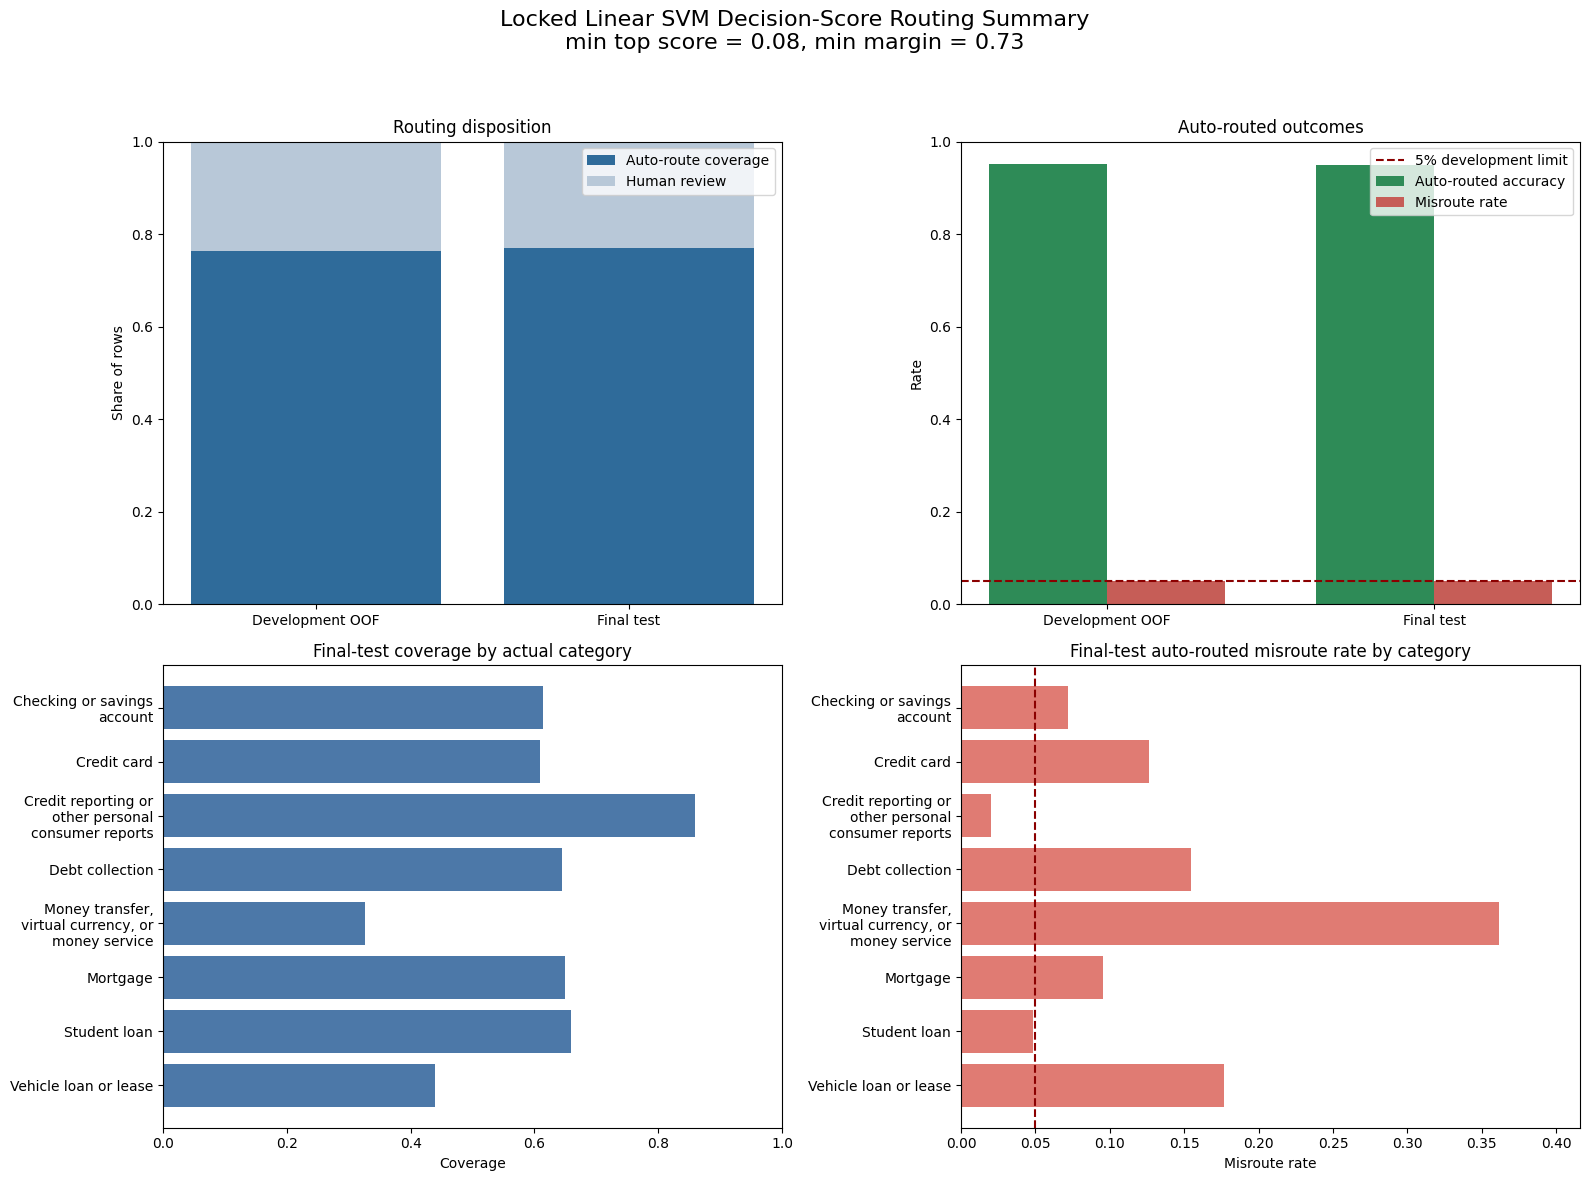

Saved aggregate routing figure: reports\figures\routing_decision_score_summary.png


In [8]:
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

overall_labels = ["Development OOF", "Final test"]
coverage_values = [
    development_routing_metrics["coverage"],
    final_routing_metrics["coverage"],
]
review_values = [
    development_routing_metrics["review_rate"],
    final_routing_metrics["review_rate"],
]
accuracy_values = [
    development_routing_metrics["auto_routed_accuracy"],
    final_routing_metrics["auto_routed_accuracy"],
]
misroute_values = [
    development_routing_metrics["misroute_rate"],
    final_routing_metrics["misroute_rate"],
]

short_category_labels = [textwrap.fill(label, 22) for label in final_category_routing.index]
y_positions = np.arange(len(short_category_labels))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(overall_labels, coverage_values, label="Auto-route coverage", color="#2F6B9A")
axes[0, 0].bar(
    overall_labels,
    review_values,
    bottom=coverage_values,
    label="Human review",
    color="#B8C8D8",
)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Routing disposition")
axes[0, 0].set_ylabel("Share of rows")
axes[0, 0].legend()

x = np.arange(len(overall_labels))
bar_width = 0.36
axes[0, 1].bar(x - bar_width / 2, accuracy_values, bar_width, label="Auto-routed accuracy", color="#2E8B57")
axes[0, 1].bar(x + bar_width / 2, misroute_values, bar_width, label="Misroute rate", color="#C65D57")
axes[0, 1].axhline(MAX_DEVELOPMENT_MISROUTE_RATE, color="#8B0000", linestyle="--", linewidth=1.5, label="5% development limit")
axes[0, 1].set_xticks(x, overall_labels)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Auto-routed outcomes")
axes[0, 1].set_ylabel("Rate")
axes[0, 1].legend()

axes[1, 0].barh(y_positions, final_category_routing["coverage"], color="#4C78A8")
axes[1, 0].set_yticks(y_positions, short_category_labels)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_title("Final-test coverage by actual category")
axes[1, 0].set_xlabel("Coverage")

axes[1, 1].barh(y_positions, final_category_routing["misroute_rate"].fillna(0), color="#E07B73")
axes[1, 1].axvline(MAX_DEVELOPMENT_MISROUTE_RATE, color="#8B0000", linestyle="--", linewidth=1.5)
axes[1, 1].set_yticks(y_positions, short_category_labels)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlim(0, max(0.10, float(final_category_routing["misroute_rate"].max()) * 1.15))
axes[1, 1].set_title("Final-test auto-routed misroute rate by category")
axes[1, 1].set_xlabel("Misroute rate")

fig.suptitle(
    "Locked Linear SVM Decision-Score Routing Summary\n"
    f"min top score = {LOCKED_MIN_TOP_SCORE:.2f}, min margin = {LOCKED_MIN_SCORE_MARGIN:.2f}",
    fontsize=16,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved aggregate routing figure: {FIGURE_PATH.relative_to(PROJECT_ROOT)}")

## 9. Interpretation and Limitations

- The policy is a development exercise for prioritizing human review, not a deployment or production-readiness claim.
- Decision scores and top-two margins are not probabilities and do not quantify real-world confidence.
- The 5% maximum development misroute rate is a project assumption, not a business-approved risk tolerance.
- Thresholds were selected on development OOF results and evaluated once on the locked internal 2024 final test set. The 2025 dataset was not loaded or used.
- Category-level estimates for smaller products are less stable because both final-test support and auto-routed counts are limited.
- A production policy would require stakeholder-approved error costs, monitoring, calibration analysis, and dedicated out-of-time validation.